# Data Importing and Preprocessing

**Topics:** EDA · Missing Values · Outlier Detection · Encoding · Scaling · Normalization · Binning · Smoothing · Feature Engineering · Correlation · Train/Test Split

## 1. Library Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute        import SimpleImputer, KNNImputer
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder,
                                   StandardScaler, MinMaxScaler,
                                   RobustScaler, PowerTransformer)
from sklearn.model_selection import train_test_split
from scipy.ndimage           import gaussian_filter1d
from scipy.stats             import zscore

import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset
We use the **House Price** dataset — tabular data describing city-level housing features with `price` as the regression target.

In [ ]:
df = pd.read_csv('House_Price.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (506, 19)


,price,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,parks
0,24.0,0.00632,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,YES,5.480,11.1920,River,23,YES,0.049347
1,21.6,0.02731,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,NO,7.332,12.1728,Lake,42,YES,0.046146
2,34.7,0.02729,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,NO,7.394,101.1200,NaN,38,YES,0.045764
3,33.4,0.03237,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,YES,9.268,11.2672,Lake,45,YES,0.047151
4,36.2,0.06905,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,NO,8.824,11.2896,Lake,55,YES,0.039474


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        506 non-null    float64
 1   crime_rate   506 non-null    float64
 2   resid_area   506 non-null    float64
 3   air_qual     506 non-null    float64
 4   room_num     506 non-null    float64
 5   age          506 non-null    float64
 6   dist1        506 non-null    float64
 7   dist2        506 non-null    float64
 8   dist3        506 non-null    float64
 9   dist4        506 non-null    float64
 10  teachers     506 non-null    float64
 11  poor_prop    506 non-null    float64
 12  airport      506 non-null    object 
 13  n_hos_beds   498 non-null    float64
 14  n_hot_rooms  506 non-null    float64
 15  waterbody    351 non-null    object 
 16  rainfall     506 non-null    int64  
 17  bus_ter      506 non-null    object 
 18  parks        506 non-null    float64
dtypes: float

## 3. Exploratory Data Analysis (EDA)

Understand the dataset:  
data types, size, statistics, and missing values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        506 non-null    float64
 1   crime_rate   506 non-null    float64
 2   resid_area   506 non-null    float64
 3   air_qual     506 non-null    float64
 4   room_num     506 non-null    float64
 5   age          506 non-null    float64
 6   dist1        506 non-null    float64
 7   dist2        506 non-null    float64
 8   dist3        506 non-null    float64
 9   dist4        506 non-null    float64
 10  teachers     506 non-null    float64
 11  poor_prop    506 non-null    float64
 12  airport      506 non-null    object 
 13  n_hos_beds   498 non-null    float64
 14  n_hot_rooms  506 non-null    float64
 15  waterbody    351 non-null    object 
 16  rainfall     506 non-null    int64  
 17  bus_ter      506 non-null    object 
 18  parks        506 non-null    float64
dtypes: float

In [ ]:
df.describe()

,price,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,n_hos_beds,n_hot_rooms,rainfall,parks
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,498.000000,506.000000,506.000000,506.000000
mean,22.528854,3.613524,41.136779,0.554695,6.284634,68.574901,3.971996,3.628775,3.960672,3.618972,21.544466,12.653063,7.899767,13.041605,39.181818,0.054454
std,9.182176,8.601545,6.860353,0.115878,0.702617,28.148861,2.108532,2.108580,2.119797,2.099203,2.164946,7.141062,1.476683,5.238957,12.513697,0.010632
min,5.000000,0.006320,30.460000,0.385000,3.561000,2.900000,1.130000,0.920000,1.150000,0.730000,18.000000,1.730000,5.268000,10.057600,3.000000,0.033292
25%,17.025000,0.082045,35.190000,0.449000,5.885500,45.025000,2.270000,1.940000,2.232500,1.940000,19.800000,6.950000,6.634500,11.189800,28.000000,0.046464
50%,21.200000,0.256510,39.690000,0.538000,6.208500,77.500000,3.385000,3.010000,3.375000,3.070000,20.950000,11.360000,7.999000,12.720000,39.000000,0.053507
75%,25.000000,3.677083,48.100000,0.624000,6.623500,94.075000,5.367500,4.992500,5.407500,4.985000,22.600000,16.955000,9.088000,14.170800,50.000000,0.061397
max,50.000000,88.976200,57.740000,0.871000,8.780000,100.000000,12.320000,11.930000,12.320000,11.940000,27.400000,37.970000,10.876000,101.120000,60.000000,0.086711


In [ ]:
# Missing values per column
df.isnull().sum()

price            0
crime_rate       0
resid_area       0
air_qual         0
room_num         0
age              0
dist1            0
dist2            0
dist3            0
dist4            0
teachers         0
poor_prop        0
airport          0
n_hos_beds       8
n_hot_rooms      0
waterbody      155
rainfall         0
bus_ter          0
parks            0
dtype: int64

## 4. Rename Column Names
Keep names descriptive and consistent (snake_case) so you can recognise each variable.

In [ ]:
df.rename(columns={
    'n_hos_beds':  'hospital_beds',
    'n_hot_rooms': 'hotel_rooms',
    'poor_prop':   'poverty_rate',
    'bus_ter':     'has_bus_terminal',
}, inplace=True)

df.columns.tolist()

['price',
 'crime_rate',
 'resid_area',
 'air_qual',
 'room_num',
 'age',
 'dist1',
 'dist2',
 'dist3',
 'dist4',
 'teachers',
 'poverty_rate',
 'airport',
 'hospital_beds',
 'hotel_rooms',
 'waterbody',
 'rainfall',
 'has_bus_terminal',
 'parks']

## 5. Visualise Data

### 5a. Numerical Features — Histograms

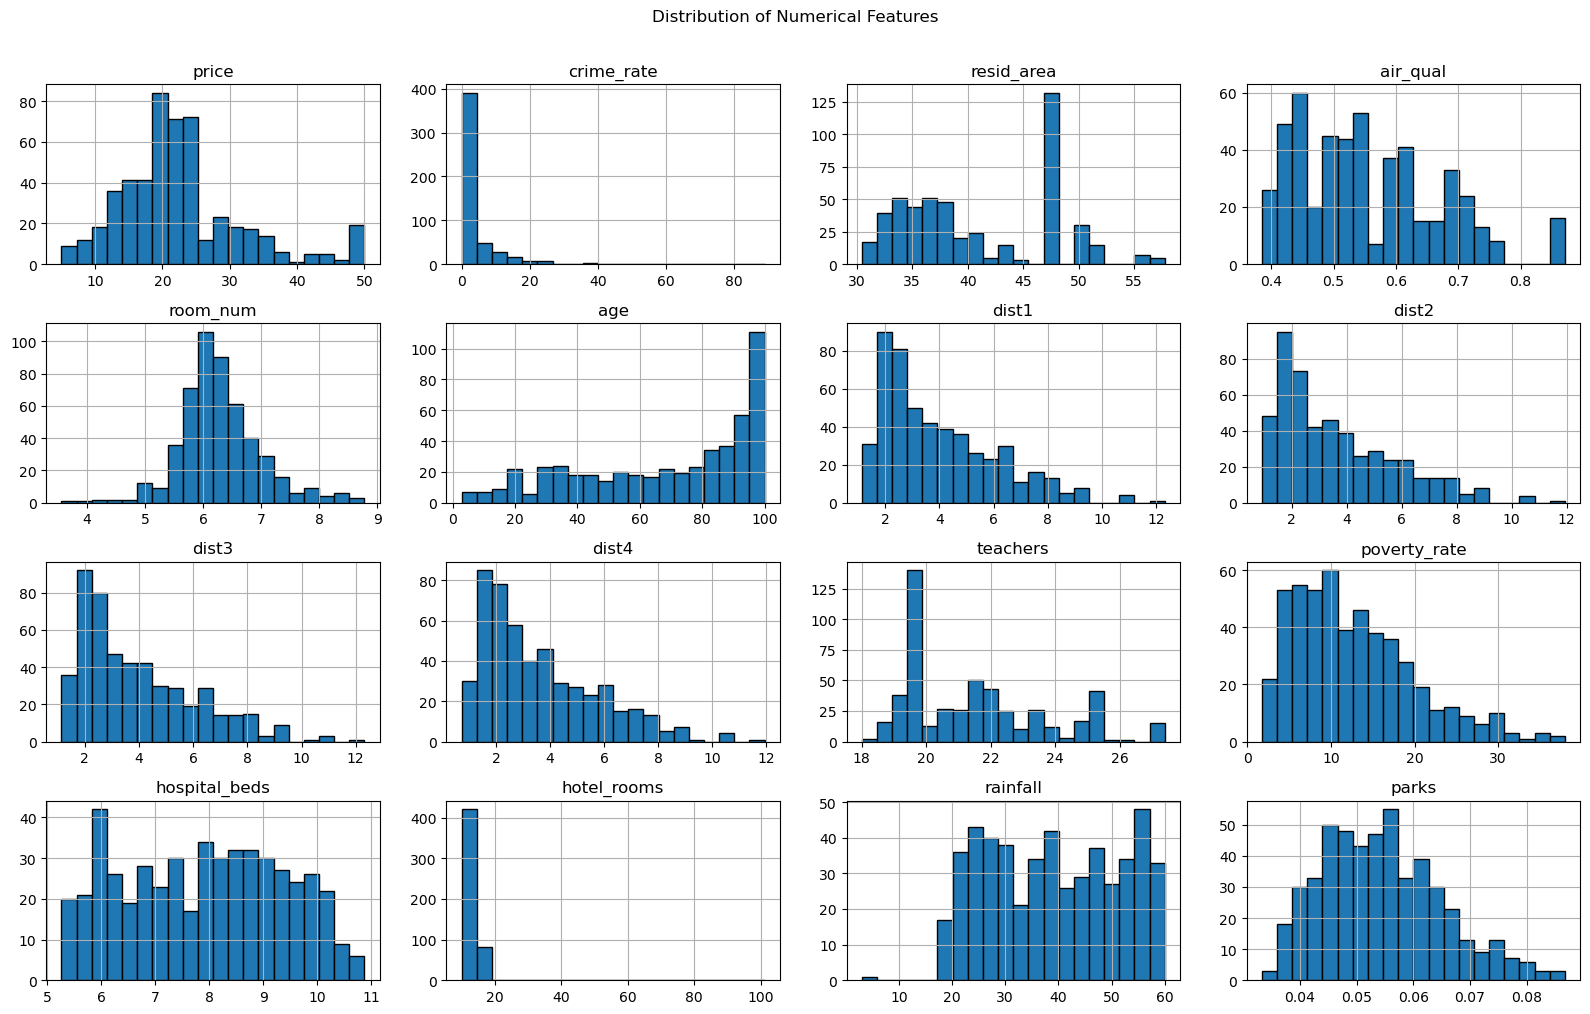

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(figsize=(16, 10), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

### 5b. Categorical Features — Bar Charts

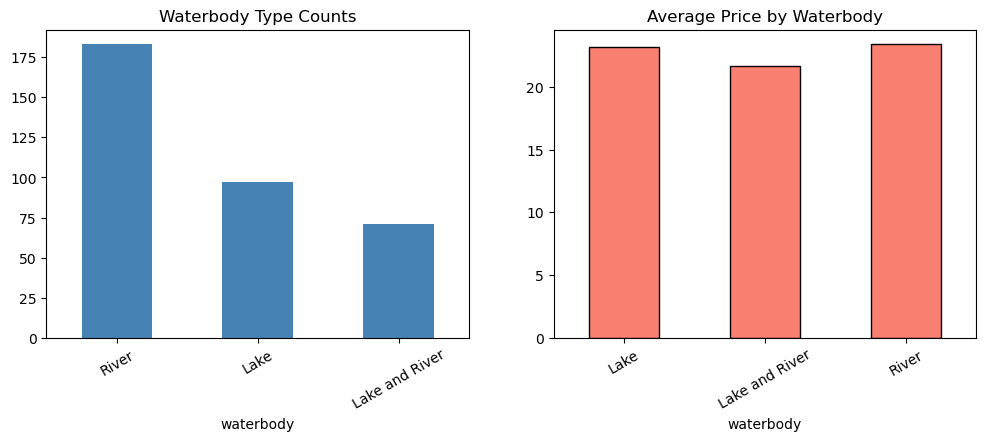

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['waterbody'].value_counts().plot.bar(
    ax=axes[0], color='steelblue')
axes[0].set_title('Waterbody Type Counts')
axes[0].tick_params(axis='x', rotation=30)

df.groupby('waterbody')['price'].mean().plot.bar(
    ax=axes[1], color='salmon', edgecolor='k')
axes[1].set_title('Average Price by Waterbody')
axes[1].tick_params(axis='x', rotation=30)

plt.show()

## 6. Train / Test Split

- `test_size=0.2` → 80 % train, 20 % test (a common default).  
- `random_state=1` → reproducible results.  
- **Preprocess after splitting** to prevent data leakage.

In [ ]:
train, test = train_test_split(
    df, test_size=0.2, random_state=1
)

In [ ]:
print(f'Train: {train.shape}  |  Test: {test.shape}')

Train: (404, 19)  |  Test: (102, 19)


In [ ]:
# Define features and target
X = df.drop(columns='price')
y = df['price']
X

,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poverty_rate,airport,hospital_beds,hotel_rooms,waterbody,rainfall,has_bus_terminal,parks
0,0.00632,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,YES,5.480,11.1920,River,23,YES,0.049347
1,0.02731,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,NO,7.332,12.1728,Lake,42,YES,0.046146
2,0.02729,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,NO,7.394,101.1200,NaN,38,YES,0.045764
3,0.03237,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,YES,9.268,11.2672,Lake,45,YES,0.047151
4,0.06905,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,NO,8.824,11.2896,Lake,55,YES,0.039474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,41.93,0.573,6.593,69.1,2.64,2.45,2.76,2.06,19.0,9.67,NO,9.348,12.1792,Lake and River,27,YES,0.056006
502,0.04527,41.93,0.573,6.120,76.7,2.44,2.11,2.46,2.14,19.0,9.08,YES,6.612,13.1648,Lake and River,20,YES,0.059903
503,0.06076,41.93,0.573,6.976,91.0,2.34,2.06,2.29,1.98,19.0,5.64,NO,5.478,12.1912,NaN,31,YES,0.057572
504,0.10959,41.93,0.573,6.794,89.3,2.54,2.31,2.40,2.31,19.0,6.48,YES,7.940,15.1760,NaN,47,YES,0.060694


In [ ]:
print(f'Features: {X.shape[1]}  |  Samples: {X.shape[0]}')

Features: 18  |  Samples: 506


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print(f'Train: {x_train.shape}  |  Test: {x_test.shape}')

Train: (404, 18)  |  Test: (102, 18)


## 7. Handling Missing Values
Three strategies:
- **Drop** — if a column has too many missing values.
- **Impute** — fill with mean / median / mode / a constant.
- **Flag** — when missing value itself is informative.

In [ ]:
# Numerical columns: impute with median (robust to outliers)
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
numeric_imputer = SimpleImputer(strategy='median')

train[numeric_cols] = numeric_imputer.fit_transform(train[numeric_cols])

In [ ]:
test[numeric_cols] = numeric_imputer.transform(test[numeric_cols])

In [ ]:
# Categorical column: impute with mode
categorical_imputer = SimpleImputer(strategy='most_frequent')

train[['waterbody']] = categorical_imputer.fit_transform(train[['waterbody']])

In [ ]:
test[['waterbody']] = categorical_imputer.transform(test[['waterbody']])

In [ ]:
train.head()

,price,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,parks
42,25.3,0.14150,36.91,0.448,6.169,6.6,5.93,5.46,5.88,5.62,22.1,5.81,NO,8.106,15.2024,River,52.0,YES,0.041830
58,23.3,0.15445,35.13,0.453,6.145,29.2,7.98,7.77,8.07,7.44,20.3,6.86,NO,7.866,14.1864,River,22.0,YES,0.043784
385,7.2,16.81180,48.10,0.700,5.277,98.1,1.46,1.23,1.62,1.40,19.8,30.81,NO,10.144,13.0576,Lake and River,36.0,YES,0.059991
78,21.2,0.05646,42.83,0.437,6.232,53.7,5.34,5.00,5.10,4.62,21.3,12.34,YES,8.824,15.1696,Lake,53.0,YES,0.037647
424,11.7,8.79212,48.10,0.584,5.565,70.6,2.26,1.99,2.38,1.63,19.8,17.16,NO,7.834,11.0936,River,57.0,YES,0.063779


In [ ]:
# Confirm
print('Remaining missing values in train:', train.isnull().sum().sum())
print('Remaining missing values in test:', test.isnull().sum().sum())

Remaining missing values in train: 0
Remaining missing values in test: 0


### Alternative: KNN Imputer
`KNNImputer` fills missing values using the k nearest neighbours — smarter than a simple mean/median when features are correlated.

In [ ]:
# Demonstration only (apply to a copy)
df_knn = df.select_dtypes(include=np.number).copy()
df_knn.iloc[0, 2] = np.nan   # artificially introduce a NaN
df_knn.iloc[1, 2] = np.nan 
df_knn.iloc[2, 2] = np.nan 
df_knn.iloc[3, 2] = np.nan 
df_knn

,price,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,n_hos_beds,n_hot_rooms,rainfall,parks
0,24.0,0.00632,NaN,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,5.480,11.1920,23,0.049347
1,21.6,0.02731,NaN,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,7.332,12.1728,42,0.046146
2,34.7,0.02729,NaN,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,7.394,101.1200,38,0.045764
3,33.4,0.03237,NaN,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,9.268,11.2672,45,0.047151
4,36.2,0.06905,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,8.824,11.2896,55,0.039474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,22.4,0.06263,41.93,0.573,6.593,69.1,2.64,2.45,2.76,2.06,19.0,9.67,9.348,12.1792,27,0.056006
502,20.6,0.04527,41.93,0.573,6.120,76.7,2.44,2.11,2.46,2.14,19.0,9.08,6.612,13.1648,20,0.059903
503,23.9,0.06076,41.93,0.573,6.976,91.0,2.34,2.06,2.29,1.98,19.0,5.64,5.478,12.1912,31,0.057572
504,22.0,0.10959,41.93,0.573,6.794,89.3,2.54,2.31,2.40,2.31,19.0,6.48,7.940,15.1760,47,0.060694


In [ ]:
knn_imputer = KNNImputer(n_neighbors=5)
df_knn_filled = pd.DataFrame(
    knn_imputer.fit_transform(df_knn),
    columns=df_knn.columns
)
print('KNN imputed — missing values:', df_knn_filled.isnull().sum().sum())

KNN imputed — missing values: 0


In [ ]:
df_knn_filled

,price,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,n_hos_beds,n_hot_rooms,rainfall,parks
0,24.0,0.00632,37.702,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,5.480,11.1920,23.0,0.049347
1,21.6,0.02731,40.420,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,7.332,12.1728,42.0,0.046146
2,34.7,0.02729,37.098,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,7.394,101.1200,38.0,0.045764
3,33.4,0.03237,33.908,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,9.268,11.2672,45.0,0.047151
4,36.2,0.06905,32.180,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,8.824,11.2896,55.0,0.039474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,22.4,0.06263,41.930,0.573,6.593,69.1,2.64,2.45,2.76,2.06,19.0,9.67,9.348,12.1792,27.0,0.056006
502,20.6,0.04527,41.930,0.573,6.120,76.7,2.44,2.11,2.46,2.14,19.0,9.08,6.612,13.1648,20.0,0.059903
503,23.9,0.06076,41.930,0.573,6.976,91.0,2.34,2.06,2.29,1.98,19.0,5.64,5.478,12.1912,31.0,0.057572
504,22.0,0.10959,41.930,0.573,6.794,89.3,2.54,2.31,2.40,2.31,19.0,6.48,7.940,15.1760,47.0,0.060694


## 8. Outlier Detection & Treatment
Outliers can distort model training. Two common detection methods:
- **IQR method** — flag values outside [Q1 − 1.5·IQR, Q3 + 1.5·IQR].

IQR outliers in price: 28


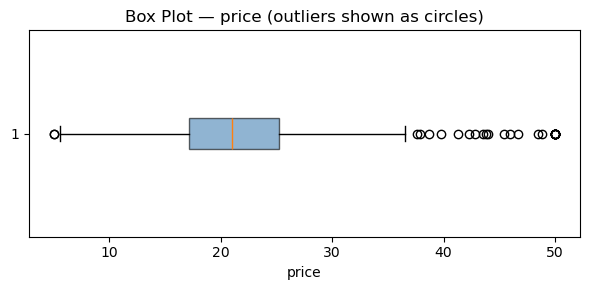

In [ ]:
# --- IQR method on 'price' ---
Q1  = train['price'].quantile(0.25)
Q3  = train['price'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers_iqr = train[(df['price'] < lower) | (train['price'] > upper)]
print(f'IQR outliers in price: {len(outliers_iqr)}')

# Visualise with box plot
plt.figure(figsize=(6, 3))
plt.boxplot(train['price'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
plt.title('Box Plot — price (outliers shown as circles)')
plt.xlabel('price')
plt.tight_layout()
plt.show()

## 9. Feature Engineering & Transformations
### Drop Redundant Columns
We drop `has_bus_terminal` — it adds little predictive power.  
We also combine the four distance columns into a single average feature to reduce dimensionality.

In [ ]:
# Drop low-value column
train.drop(columns=['has_bus_terminal'], inplace=True, errors='ignore')
test.drop(columns=['has_bus_terminal'], inplace=True, errors='ignore')

# Combine 4 distance columns → 1 average distance
dist_cols = ['dist1', 'dist2', 'dist3', 'dist4']
train['avg_dist'] = train[dist_cols].mean(axis=1)
train.drop(columns=dist_cols, inplace=True)

test['avg_dist'] = test[dist_cols].mean(axis=1)
test.drop(columns=dist_cols, inplace=True)

print(f'Train data shape after feature engineering: {train.shape}')

Train data shape after feature engineering: (404, 16)


## 10. Encoding Categorical Variables
### 10a. One-Hot Encoding 
Creates a binary column per category. Use when there is **no ordinal relationship** between categories.

In [85]:
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

train_enc = enc.fit_transform(train[['waterbody']])
test_enc  = enc.transform(test[['waterbody']])

In [86]:
ohe_cols = enc.get_feature_names_out(['waterbody'])

In [87]:
train_ohe = pd.DataFrame(
    train_enc,
    columns=ohe_cols,
    index=train.index
)

test_ohe = pd.DataFrame(
    test_enc,
    columns=ohe_cols,
    index=test.index
)

In [88]:
train_ohe

,waterbody_Lake,waterbody_Lake and River,waterbody_River
42,0.0,0.0,1.0
58,0.0,0.0,1.0
385,0.0,1.0,0.0
78,1.0,0.0,0.0
424,0.0,0.0,1.0
...,...,...,...
255,0.0,0.0,1.0
72,0.0,0.0,1.0
396,0.0,0.0,1.0
235,0.0,0.0,1.0


In [89]:
train_final = pd.concat(
    [train.drop(['waterbody'], axis=1),
     train_ohe],
    axis=1
)

In [90]:
test_final = pd.concat(
    [test.drop(['waterbody'], axis=1),
     test_ohe],
    axis=1
)

In [91]:
train_final.head()

,price,crime_rate,resid_area,air_qual,room_num,age,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,rainfall,bus_ter,parks,avg_dist,waterbody_Lake,waterbody_Lake and River,waterbody_River
42,25.3,0.14150,36.91,0.448,6.169,6.6,22.1,5.81,NO,8.106,15.2024,52.0,YES,0.041830,5.7225,0.0,0.0,1.0
58,23.3,0.15445,35.13,0.453,6.145,29.2,20.3,6.86,NO,7.866,14.1864,22.0,YES,0.043784,7.8150,0.0,0.0,1.0
385,7.2,16.81180,48.10,0.700,5.277,98.1,19.8,30.81,NO,10.144,13.0576,36.0,YES,0.059991,1.4275,0.0,1.0,0.0
78,21.2,0.05646,42.83,0.437,6.232,53.7,21.3,12.34,YES,8.824,15.1696,53.0,YES,0.037647,5.0150,1.0,0.0,0.0
424,11.7,8.79212,48.10,0.584,5.565,70.6,19.8,17.16,NO,7.834,11.0936,57.0,YES,0.063779,2.0650,0.0,0.0,1.0


### 10b. Ordinal Encoding
Maps each category to an integer. Useful for **ordinal** data or tree-based models.  

## 11. Feature Scaling
Algorithms like KNN, SVM, and gradient descent are sensitive to feature scales.

| Scaler | Formula | Best for |
|--------|---------|----------|
| `StandardScaler` | (x − μ) / σ | Normally distributed data |
| `MinMaxScaler` | (x − min) / (max − min) | Bounded output [0, 1] |

> Always fit the scaler on the **training set only**, then transform both sets.

In [ ]:
col = train.select_dtypes(include=np.number).dropna()

In [95]:
col

,price
42,25.3
58,23.3
385,7.2
78,21.2
424,11.7
...,...
255,20.9
72,22.8
396,12.5
235,24.0


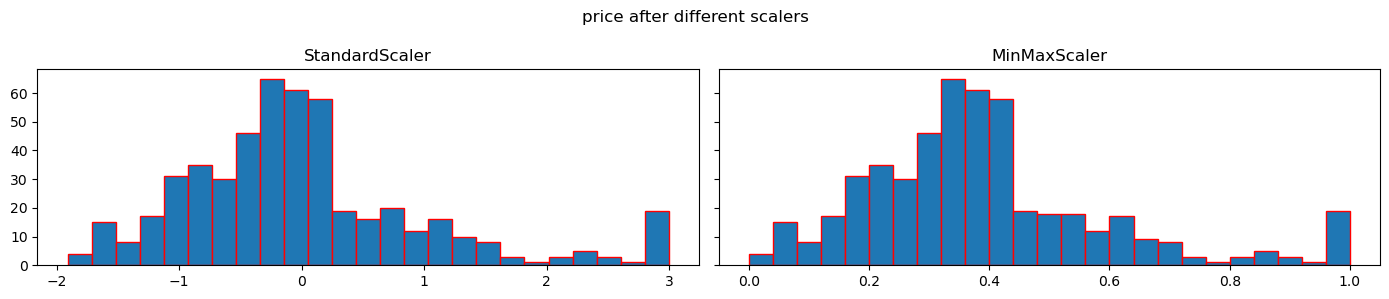

In [96]:
# compare three scalers on the 'price' column
col = df.select_dtypes(include=np.number)[['price']].dropna()

ss = StandardScaler().fit_transform(col)
mm = MinMaxScaler().fit_transform(col)

fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=True)
for ax, data, title, color in zip(
    axes,
    [ss, mm],
    ['StandardScaler', 'MinMaxScaler'],
    ['steelblue', 'steelblue']
):
    ax.hist(data, bins=25, edgecolor='r')
    ax.set_title(title)
plt.suptitle('price after different scalers')
plt.tight_layout()
plt.show()

## 12. Binning (Discretisation)
**Binning** converts a continuous feature into discrete intervals (categories).

Useful when:
- The relationship between a feature and the target is non-linear.
- You want to reduce the effect of measurement noise or outliers.
- You need a categorical variable for grouping or visualisation.

| Method | How |
|--------|-----|
| `pd.cut` | Equal-width bins (Equall Range) |
| `pd.qcut` | Equal-frequency bins (In each quartile)| 

In [23]:
# --- Equal-Width Binning with pd.cut ---
# Splits [min, max] into N intervals of the same width.
df['age_bin'] = pd.cut(
    df['age'],
    bins=4,
    labels=['New', 'Moderate', 'Old', 'Very Old']
)

print('Equal-width bin counts:')
print(df['age_bin'].value_counts().sort_index())

Equal-width bin counts:
age_bin
New          51
Moderate     97
Old          96
Very Old    262
Name: count, dtype: int64


In [24]:
# --- Equal-Frequency Binning with pd.qcut ---
df['price_quartile'] = pd.qcut(
    df['price'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

print(df['price_quartile'].value_counts().sort_index())

price_quartile
Low            127
Medium-Low     129
Medium-High    126
High           124
Name: count, dtype: int64


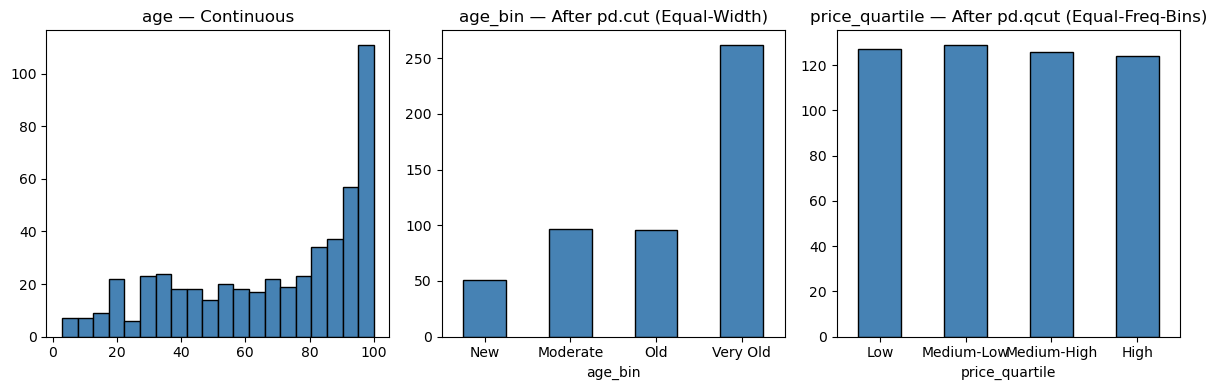

In [25]:
# Visualise: continuous vs binned
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].hist(df['age'], bins=20, edgecolor='black', color='steelblue')
axes[0].set_title('age — Continuous')

df['age_bin'].value_counts().sort_index().plot.bar(
    ax=axes[1], color='steelblue', edgecolor='black', rot=0)
axes[1].set_title('age_bin — After pd.cut (Equal-Width)')

df['price_quartile'].value_counts().sort_index().plot.bar(
    ax=axes[2], color='steelblue', edgecolor='black', rot=0)
axes[2].set_title('price_quartile — After pd.qcut (Equal-Freq-Bins)')

plt.tight_layout()
plt.show()

# Note: price_quartile can be used as a classification target in future labs

## 13. Smoothing
**Smoothing** reduces noise so underlying trends become clearer.  
Common in time-series, sensor data, and signal processing.

| **SMA** | Simple Moving Average| Simple noise reduction |

In [26]:
# Sort rainfall to simulate an ordered time-like sequence
rain = df['rainfall']
rain

0      23.0
1      42.0
2      38.0
3      45.0
4      55.0
       ... 
501    27.0
502    20.0
503    31.0
504    47.0
505    45.0
Name: rainfall, Length: 506, dtype: float64

In [27]:
# Simple Moving Average
sma  = rain.rolling(window=15, min_periods=1).mean()
sma.head(20)

0     23.000000
1     32.500000
2     34.333333
3     37.000000
4     40.600000
5     42.666667
6     42.428571
7     44.125000
8     45.333333
9     45.300000
10    43.818182
11    42.083333
12    43.230769
13    42.928571
14    43.333333
15    43.666667
16    43.933333
17    45.133333
18    44.866667
19    43.000000
Name: rainfall, dtype: float64

- **SMA**: all window points weighted equally → simple, but lags AT THE BEGGINGS

## 14. Correlation Matrix
Shows how strongly each pair of numerical features moves together.  
- Values near **±1** → strong relationship.
- Values near **0** → little linear relationship.

> High correlation between two *independent* variables is called **multicollinearity** — it inflates standard errors in linear regression.

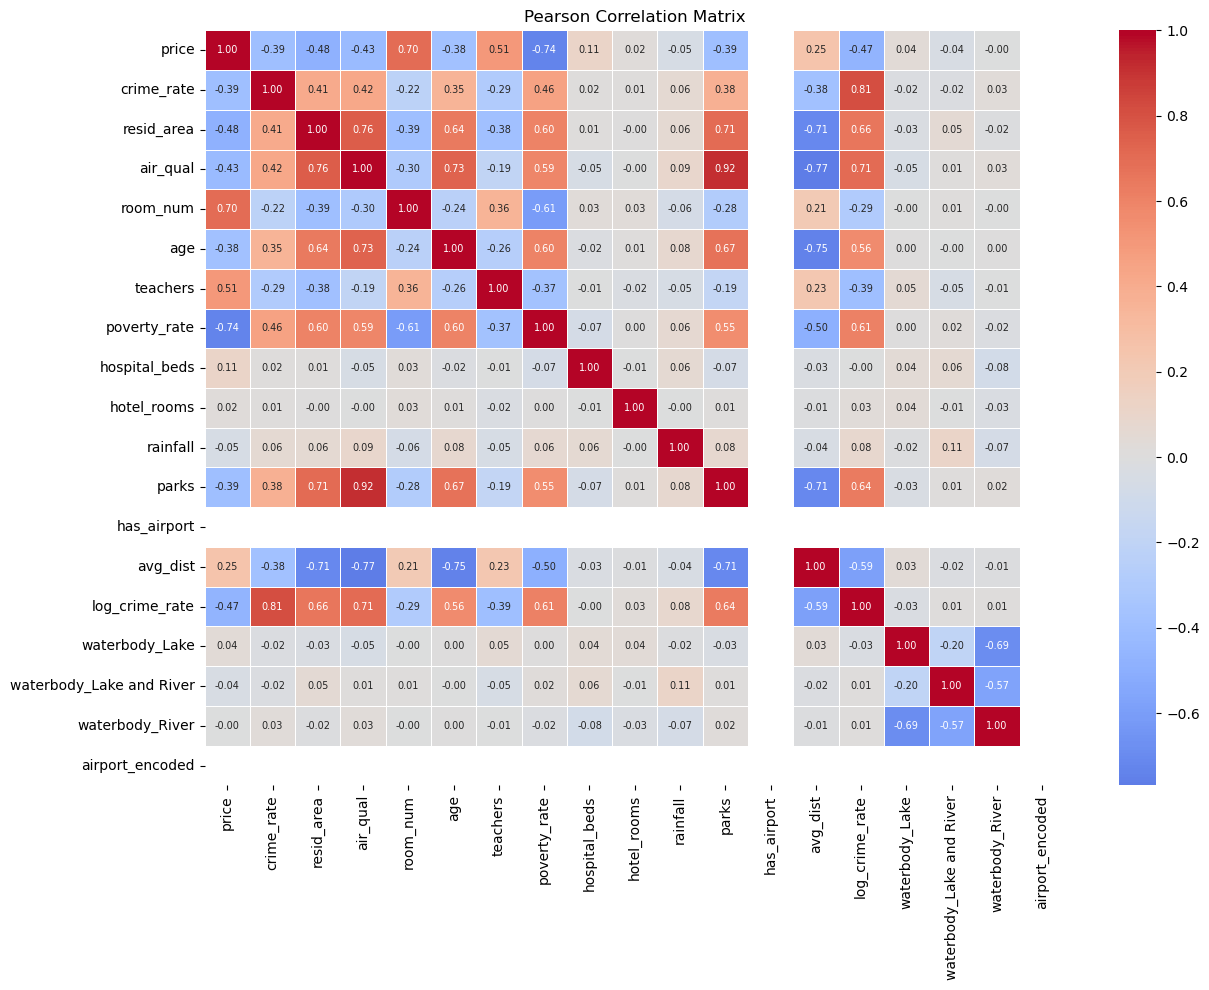

In [28]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()